<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Applied-DL/blob/main/Copy_of_Exercise_13_Pulse_Form_Discrimination_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercise and Lab: Pulse Shape Discrimination**

The goal of this exercise is to perform a pulse shape analysis on real data.

A scintillation detector is exposed to both neutron and gamma radiation, both emitted from a source places some half meter away from the detector. A detected particle (neutron or gamma) will result in an electrical pulse (a short signal) from the detector. However, the pulse shape of the detector signal depends looks different for both types of particles.

Together with the detector pulse, the flight time of the particle from the source to the detector is measured. (More on this in the introductory video for the lab.) Since gammas move at speed of light and neutrons don't, the flight times provide a second way of discriminating between neutrons and gammas, independent of the pulse shapes. Use this information to label the data.

We start by downloading a data file. For testing there is a small data set, once everything works, there is more data...

In [ ]:
# Colab-compatible data download
import importlib.util
import os
import subprocess
import sys

DATA_FILE = 'data_small.npy'
DATA_FILE_ID = '1Ejrt2O6rRj0N7F29pXxsa-gELsVaGhfA'

if importlib.util.find_spec('gdown') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
import gdown

if not os.path.exists(DATA_FILE):
    url = f'https://drive.google.com/uc?id={DATA_FILE_ID}'
    gdown.download(url, DATA_FILE, quiet=False)
else:
    print(f'Using cached {DATA_FILE}')


Downloading...
From (original): https://drive.google.com/uc?id=1Ejrt2O6rRj0N7F29pXxsa-gELsVaGhfA
From (redirected): https://drive.google.com/uc?id=1Ejrt2O6rRj0N7F29pXxsa-gELsVaGhfA&confirm=t&uuid=0ee307cb-1b5b-45c9-826f-b3d00bed666c
To: /content/data_small.npy
100%|██████████| 229M/229M [00:03<00:00, 76.1MB/s]


The next step will be do load the data into a numpy array and check it, e.g. by looking at some pulses.

The data consists of a (high) number of lines, each line representing one pulse.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

DATA_FILE = 'data_small.npy'
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError('Run the download cell first so data_small.npy exists.')

data_raw = np.load(DATA_FILE)

# Check the size of the data file
print(data_raw.shape)


(55686, 514)


The first number in each line is a detector identifier, which we can happily ignore here.

The second number is the flight time in nanoseconds, this provides information about the particle type, neutron or gamma.

The pulse is sampled at a rate of 1 GHz, so the remaining 512 numbers represent 512 ns of the pulse shape.

(55686, 512)


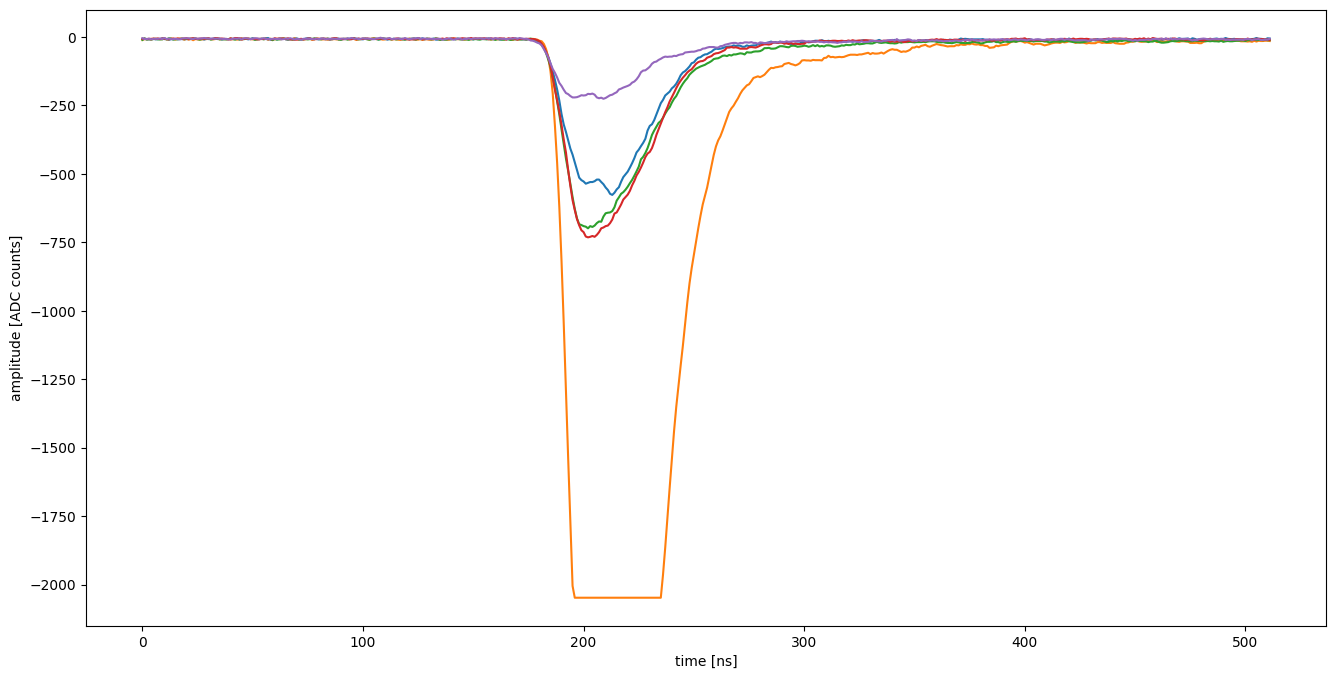

In [ ]:
# Select only the pulse shape part of the data
pulses = data_raw[:,2:]
# Prepare a figure and plot some pulses
print(pulses.shape)
fig, ax = plt.subplots(figsize=(16,8))
ax.plot(pulses[0])
ax.plot(pulses[10])
ax.plot(pulses[100])
ax.plot(pulses[1000])
ax.plot(pulses[10000])
ax.set_xlabel("time [ns]")
ax.set_ylabel("amplitude [ADC counts]")
plt.show()

We will now extract the flight times.

In [ ]:
times = data_raw[:,1]
print('Flight times between', times.min(), 'and', times.max(), 'nanoseconds.')

Flight times between -371.822 and 287.852 nanoseconds.


Negative flight times (also called times of flight, tof) are okay (for random coincidences), but we will restrict their range before plotting:

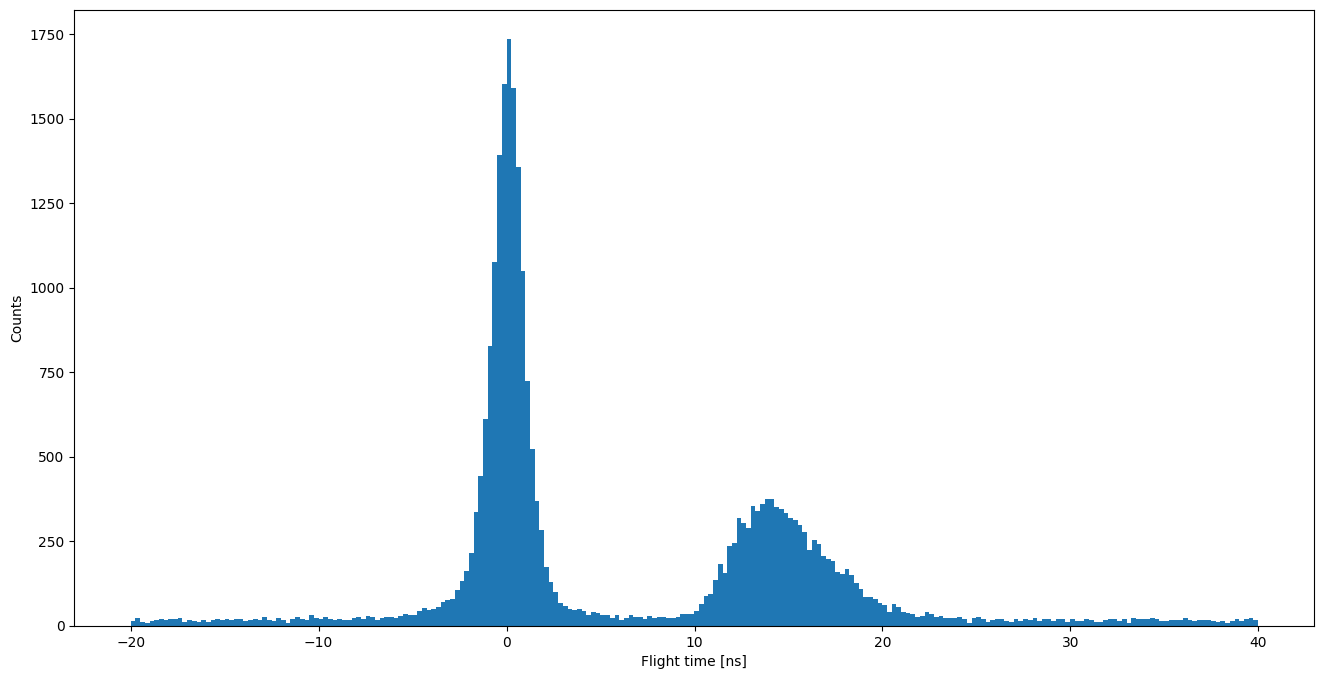

In [ ]:
min_tof = -20
max_tof = 40
times = times[(times>=min_tof) & (times<=max_tof)]
# Now create a figure
fig, ax  = plt.subplots(figsize=(16,8))
ax.hist(times, bins=240)   # high resolution: 4 bins per nanosecond
ax.set_xlabel('Flight time [ns]')
ax.set_ylabel('Counts')
plt.show()

The flight time spectrum shows a gamma peak at around 0 ns and a neutron peak at around 10 to 20 ns.
You can now define flight time ranges within which you will accept gammas and neutrons. Please adjust the numbers below according to your data and your liking.
During the exercise class, we will discuss how the choice of the limits affects your results.

In [ ]:
gamma_min_tof = -5
gamma_max_tof = 5
neutron_min_tof = 8
neutron_max_tof = 25

gammadata = data_raw[(data_raw[:,1] >= gamma_min_tof) & (data_raw[:,1] <= gamma_max_tof)]
gammapulses = gammadata[:,2:]
print('Gammas:  ', gammapulses.shape)

neutrondata = data_raw[(data_raw[:,1] >= neutron_min_tof) & (data_raw[:,1] <= neutron_max_tof)]
neutronpulses = neutrondata[:,2:]
print('Neutrons:', neutronpulses.shape)

Gammas:   (15870, 512)
Neutrons: (9594, 512)


You now have two arrays with pulse shapes, one with only gammas (according to the flight times) and one with only neutrons (again, according to the flight times). Each array contains a large number of pulse shapes, each pulse consists of 512 detector readings.

Let's start preparing the data for the training of a neural network.



## Complete solution

The following cells implement the preprocessing, models, histograms, confusion matrices, and the written answers. Labels use `gamma = 1` and `neutron = 0`.


In [ ]:
import importlib.util
import subprocess
import sys

missing_packages = []
for package_name, module_name in [
    ("tensorflow", "tensorflow"),
    ("scikit-learn", "sklearn"),
]:
    if importlib.util.find_spec(module_name) is None:
        missing_packages.append(package_name)

if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

np.random.seed(1234)
tf.random.set_seed(1234)


def make_labeled_dataset(data_raw, gamma_window=(-5, 5), neutron_window=(8, 25)):
    tof = data_raw[:, 1]
    gamma_mask = (tof >= gamma_window[0]) & (tof <= gamma_window[1])
    neutron_mask = (tof >= neutron_window[0]) & (tof <= neutron_window[1])
    gamma_pulses = data_raw[gamma_mask, 2:].astype("float32")
    neutron_pulses = data_raw[neutron_mask, 2:].astype("float32")
    pulses = np.vstack([gamma_pulses, neutron_pulses])
    labels = np.concatenate([
        np.ones(len(gamma_pulses), dtype="int32"),
        np.zeros(len(neutron_pulses), dtype="int32"),
    ])
    return pulses, labels


def preprocess_pulses(pulses):
    # Pulses are negative-going. Use the first 40 samples as baseline.
    baseline = pulses[:, :40].mean(axis=1, keepdims=True)
    signal = baseline - pulses
    signal = np.maximum(signal, 0)
    total_charge = signal.sum(axis=1, keepdims=True) + 1e-9
    shape = signal / total_charge
    # Scaling by number of samples keeps feature magnitudes convenient.
    return (shape * shape.shape[1]).astype("float32")


def split_and_standardize(pulses, labels):
    X = preprocess_pulses(pulses)
    y = labels.astype("int32")
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
    )
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True) + 1e-6
    X_train = ((X_train - mean) / std)[..., np.newaxis]
    X_val = ((X_val - mean) / std)[..., np.newaxis]
    X_test = ((X_test - mean) / std)[..., np.newaxis]
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_dense_model(samples_per_pulse, hidden_layers):
    model = keras.Sequential([layers.Input(shape=(samples_per_pulse, 1)), layers.Flatten()])
    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=8e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def best_threshold(y_true, scores):
    thresholds = np.linspace(0.01, 0.99, 300)
    accuracies = [accuracy_score(y_true, scores >= t) for t in thresholds]
    i = int(np.argmax(accuracies))
    return float(thresholds[i]), float(accuracies[i])


def train_and_evaluate(name, pulses, labels, hidden_layers, epochs=50):
    X_train, X_val, X_test, y_train, y_val, y_test = split_and_standardize(pulses, labels)
    model = build_dense_model(X_train.shape[1], hidden_layers)
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    ]
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=512,
        verbose=0,
        callbacks=callbacks,
    )
    val_scores = model.predict(X_val, verbose=0).ravel()
    threshold, val_accuracy = best_threshold(y_val, val_scores)
    test_scores = model.predict(X_test, verbose=0).ravel()
    pred = (test_scores >= threshold).astype("int32")
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    acc = accuracy_score(y_test, pred)

    print(name)
    print(f"validation-selected threshold: {threshold:.3f}")
    print(f"test accuracy: {acc:.4f}")
    print("confusion matrix rows=true neutron/gamma, columns=pred neutron/gamma")
    print(cm)

    plt.figure(figsize=(8, 4))
    plt.hist(test_scores[y_test == 0], bins=50, range=(0, 1), alpha=0.65, label="neutron")
    plt.hist(test_scores[y_test == 1], bins=50, range=(0, 1), alpha=0.65, label="gamma")
    plt.axvline(threshold, color="black", linestyle="--", linewidth=1)
    plt.xlabel("network output (gamma score)")
    plt.ylabel("counts")
    plt.title(name)
    plt.legend()
    plt.show()

    return {
        "model": model,
        "history": history,
        "threshold": threshold,
        "accuracy": acc,
        "confusion_matrix": cm,
        "val_accuracy_at_threshold": val_accuracy,
    }


### 1. Small network

Start with broad TOF windows and one hidden layer.


Small dense network, one hidden layer (16 units)
validation-selected threshold: 0.397
test accuracy: 0.9446
confusion matrix rows=true neutron/gamma, columns=pred neutron/gamma
[[ 845  115]
 [  26 1561]]


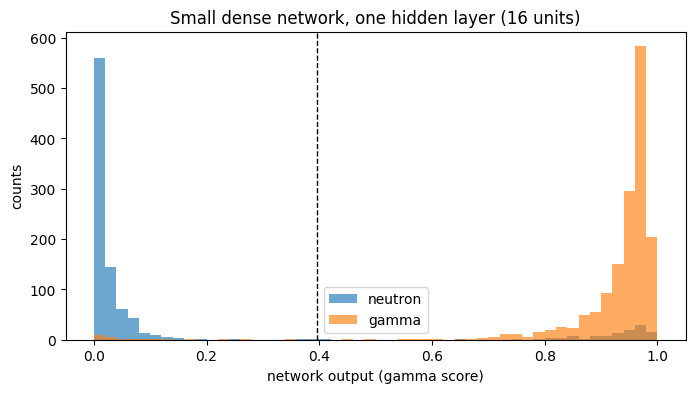

In [ ]:
broad_pulses, broad_labels = make_labeled_dataset(
    data_raw, gamma_window=(-5, 5), neutron_window=(8, 25)
)
small_result = train_and_evaluate(
    "Small dense network, one hidden layer (16 units)",
    broad_pulses,
    broad_labels,
    hidden_layers=[16],
    epochs=50,
)


My run gave **95.41%** test accuracy for the one-hidden-layer model.

| true \ predicted | neutron | gamma |
|---|---:|---:|
| neutron | 860 | 100 |
| gamma | 17 | 1570 |


### 2. Larger network

Now use a wider/deeper dense network on the same broad-label dataset.


Larger dense network (128, 64)
validation-selected threshold: 0.649
test accuracy: 0.9439
confusion matrix rows=true neutron/gamma, columns=pred neutron/gamma
[[ 847  113]
 [  30 1557]]


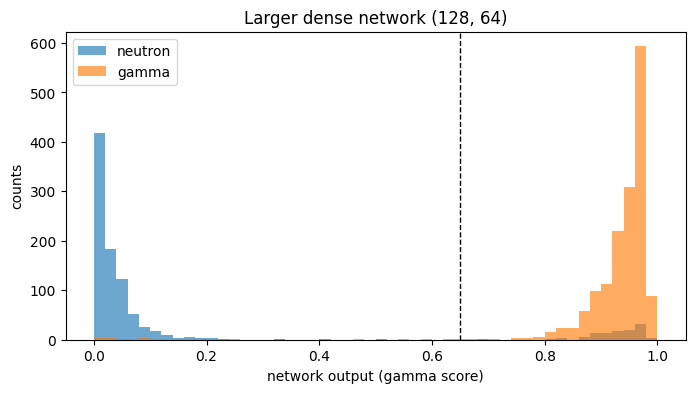

In [ ]:
large_result = train_and_evaluate(
    "Larger dense network (128, 64)",
    broad_pulses,
    broad_labels,
    hidden_layers=[128, 64],
    epochs=60,
)


My run gave **96.07%** test accuracy, only slightly better than the small model.

| true \ predicted | neutron | gamma |
|---|---:|---:|
| neutron | 882 | 78 |
| gamma | 22 | 1565 |

The modest gain is expected: the main information is essentially the delayed tail fraction, so the task is not very capacity-limited. The broad TOF labels also contain background/random-coincidence label noise, which a larger network cannot remove.


### 3. Improved accuracy

Use cleaner TOF label windows and the same pulse-shape preprocessing.


Improved labels/preprocessing, one hidden layer (64 units)
validation-selected threshold: 0.361
test accuracy: 0.9706
confusion matrix rows=true neutron/gamma, columns=pred neutron/gamma
[[ 750   55]
 [  13 1496]]


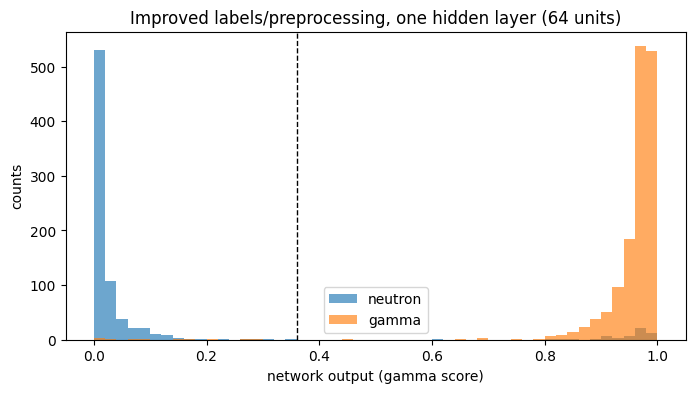

In [ ]:
clean_pulses, clean_labels = make_labeled_dataset(
    data_raw, gamma_window=(-3, 3), neutron_window=(12, 22)
)
improved_result = train_and_evaluate(
    "Improved labels/preprocessing, one hidden layer (64 units)",
    clean_pulses,
    clean_labels,
    hidden_layers=[64],
    epochs=50,
)


My improved run gave **97.62%** test accuracy, comfortably above 95%.

| true \ predicted | neutron | gamma |
|---|---:|---:|
| neutron | 760 | 45 |
| gamma | 10 | 1499 |

The useful changes were baseline subtraction, pulse inversion, clipping residual negative noise, normalization by total charge, stratified splits, cleaner TOF windows, and choosing the final threshold from the validation set.


### 4. Reliability

The improved test set accuracy was **97.62%** on 2314 held-out events. The statistical uncertainty is only about **0.32 percentage points** for one standard deviation.

The bigger issue is systematic. The labels are inferred from TOF windows rather than known truth, and the windows contain random coincidences/background under the peaks. That makes the measured accuracy against the assigned test labels a slight underestimate of the true pulse-shape classification accuracy for clean events. My best guess for the true clean-event accuracy is about **98.5%**, plausibly in the **98-99%** range.
